# Phase 1 — Data Preparation

## 1. Setup

In [1]:
import os
import re
import json
import pickle
import random
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from torchvision import transforms

import nltk
from nltk.tokenize import word_tokenize

for pkg in ["punkt", "punkt_tab"]:
    try:
        nltk.data.find(f"tokenizers/{pkg}")
    except LookupError:
        nltk.download(pkg, quiet=True)

In [2]:
# Paths
PROJECT_ROOT = Path("..").resolve()
DATA_DIR     = PROJECT_ROOT / "data"
IMAGE_DIR    = DATA_DIR / "images" / "val"
ANNOTATIONS  = DATA_DIR / "annotations" / "val.json"
PROCESSED    = DATA_DIR / "processed"
PROCESSED.mkdir(parents=True, exist_ok=True)

# Reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# Preprocessing
MIN_WORD_FREQ      = 5
MAX_CAPTION_LENGTH = 25
MIN_CAPTION_LENGTH = 3
TRAIN_RATIO, VAL_RATIO, TEST_RATIO = 0.70, 0.15, 0.15

FILTER_REJECTED  = True
FILTER_PRECANNED = True

In [3]:
assert ANNOTATIONS.exists(), f"Missing: {ANNOTATIONS}"
assert IMAGE_DIR.exists(),   f"Missing: {IMAGE_DIR}"
print(f"{len(list(IMAGE_DIR.glob('*.jpg')))} images found")

7750 images found


## 2. Load Annotations

In [4]:
def load_vizwiz_annotations(annotation_path, image_dir,
                              filter_rejected=True, filter_precanned=True):
    with open(annotation_path, "r", encoding="utf-8") as f:
        ann = json.load(f)

    images = {img["id"]: img for img in ann["images"]}

    captions_by_image = defaultdict(list)
    n_total = n_rej = n_pre = 0
    for a in ann["annotations"]:
        n_total += 1
        if filter_rejected and a.get("is_rejected", False):
            n_rej += 1; continue
        if filter_precanned and a.get("is_precanned", False):
            n_pre += 1; continue
        captions_by_image[a["image_id"]].append(a["caption"])

    data = []
    for img_id, caps in captions_by_image.items():
        meta = images[img_id]
        img_path = Path(image_dir) / meta["file_name"]
        if not img_path.exists():
            continue
        data.append({
            "image_id":     img_id,
            "file_name":    meta["file_name"],
            "image_path":   str(img_path),
            "captions_raw": caps,
        })

    print(f"total={n_total}  rejected={n_rej}  precanned={n_pre}  kept_images={len(data)}")
    return data

raw_data = load_vizwiz_annotations(
    ANNOTATIONS, IMAGE_DIR,
    filter_rejected=FILTER_REJECTED,
    filter_precanned=FILTER_PRECANNED,
)
raw_data[0]

total=38750  rejected=964  precanned=4641  kept_images=7542


{'image_id': 23431,
 'file_name': 'VizWiz_val_00000000.jpg',
 'image_path': 'D:\\DL_Assignment_3_Group31\\data\\images\\val\\VizWiz_val_00000000.jpg',
 'captions_raw': ['A computer screen shows a repair prompt on the screen.',
  'a computer screen with a repair automatically pop up',
  'partial computer screen showing the need of repairs',
  'Part of a computer monitor showing a computer repair message.',
  'The top of a laptop with a blue background and dark blue text.']}

## 3. EDA

n=33145  mean=12.1  p95=20  max=155


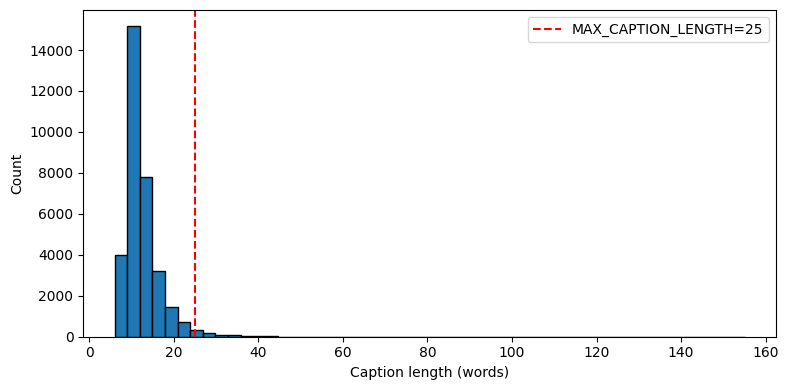

In [5]:
# Caption length distribution
lengths = [len(c.split()) for d in raw_data for c in d["captions_raw"]]

print(f"n={len(lengths)}  mean={np.mean(lengths):.1f}  "
      f"p95={np.percentile(lengths,95):.0f}  max={max(lengths)}")

plt.figure(figsize=(8, 4))
plt.hist(lengths, bins=50, edgecolor="black")
plt.axvline(MAX_CAPTION_LENGTH, color="red", linestyle="--",
            label=f"MAX_CAPTION_LENGTH={MAX_CAPTION_LENGTH}")
plt.xlabel("Caption length (words)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

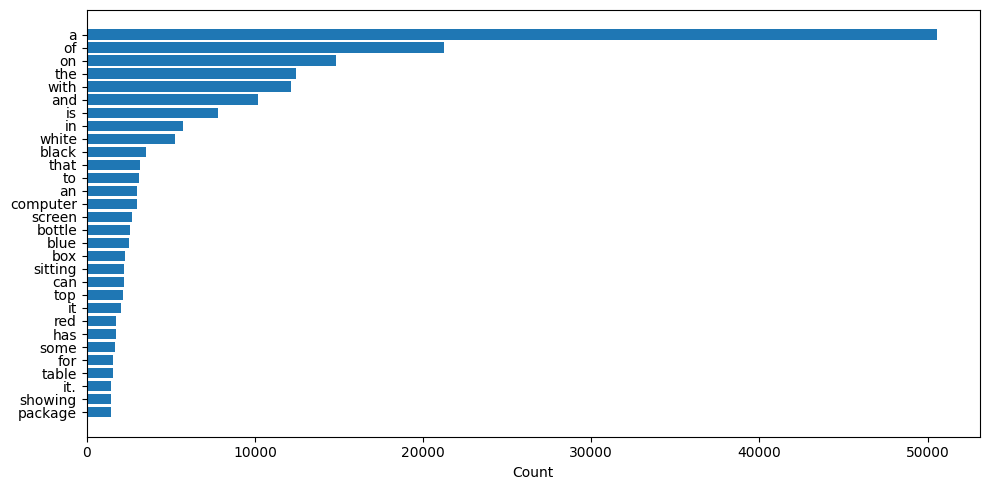

unique_words_raw=16,672


In [6]:
# Top 30 most frequent words (raw)
all_words = [w.lower() for d in raw_data for c in d["captions_raw"] for w in c.split()]
counter = Counter(all_words)
words, counts = zip(*counter.most_common(30))

plt.figure(figsize=(10, 5))
plt.barh(range(len(words)), counts)
plt.yticks(range(len(words)), words)
plt.gca().invert_yaxis()
plt.xlabel("Count")
plt.tight_layout()
plt.show()

print(f"unique_words_raw={len(counter):,}")

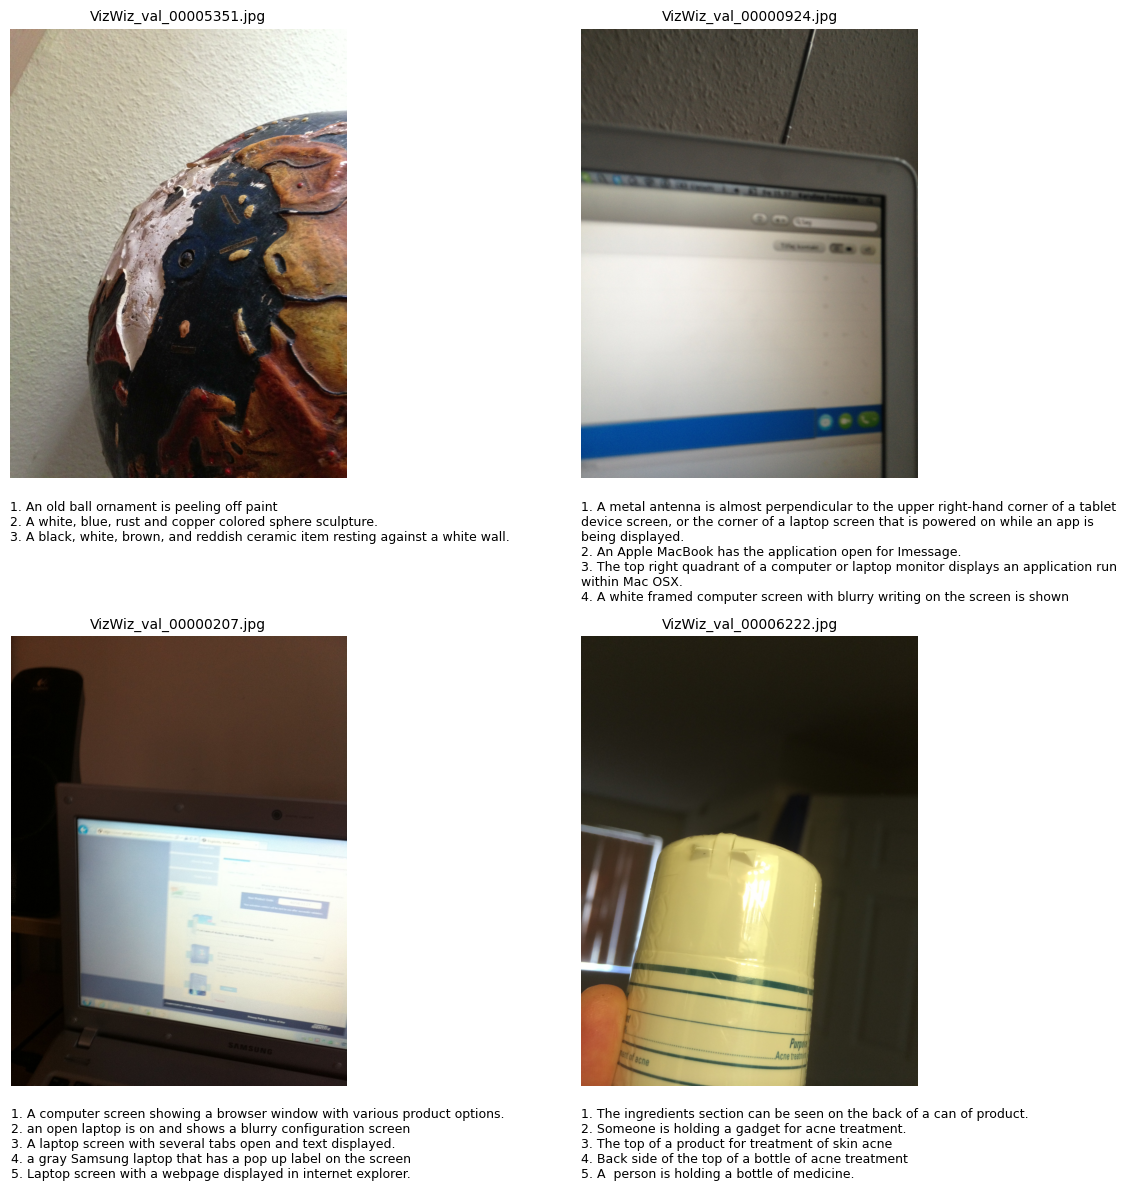

In [7]:
# 4 random samples with their captions
sample_indices = random.sample(range(len(raw_data)), 4)

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
for ax, idx in zip(axes.flat, sample_indices):
    item = raw_data[idx]
    ax.imshow(Image.open(item["image_path"]).convert("RGB"))
    ax.axis("off")
    caps = "\n".join(f"{i+1}. {c}" for i, c in enumerate(item["captions_raw"]))
    ax.set_title(item["file_name"], fontsize=10)
    ax.text(0, -0.05, caps, transform=ax.transAxes, fontsize=9, va="top", wrap=True)
plt.tight_layout()
plt.show()

## 4. Clean & Tokenize

In [8]:
PUNCT_RE      = re.compile(r"[^a-z0-9'\s]")
WHITESPACE_RE = re.compile(r"\s+")

def clean_caption(text):
    text = text.lower().strip()
    text = PUNCT_RE.sub(" ", text)
    text = WHITESPACE_RE.sub(" ", text).strip()
    return text

def tokenize(text):
    return word_tokenize(text)

# Sanity check
for c in raw_data[0]["captions_raw"][:2]:
    print("RAW   :", c)
    print("CLEAN :", clean_caption(c))
    print("TOKENS:", tokenize(clean_caption(c)))
    print("-" * 60)

RAW   : A computer screen shows a repair prompt on the screen.
CLEAN : a computer screen shows a repair prompt on the screen
TOKENS: ['a', 'computer', 'screen', 'shows', 'a', 'repair', 'prompt', 'on', 'the', 'screen']
------------------------------------------------------------
RAW   : a computer screen with a repair automatically pop up
CLEAN : a computer screen with a repair automatically pop up
TOKENS: ['a', 'computer', 'screen', 'with', 'a', 'repair', 'automatically', 'pop', 'up']
------------------------------------------------------------


In [9]:
def process_captions(data, min_len, max_len):
    out = []
    n_short = n_trunc = 0
    for item in tqdm(data, desc="Tokenizing"):
        new_caps = []
        for cap in item["captions_raw"]:
            tokens = tokenize(clean_caption(cap))
            if len(tokens) < min_len:
                n_short += 1; continue
            if len(tokens) > max_len:
                tokens = tokens[:max_len]; n_trunc += 1
            new_caps.append(tokens)
        if new_caps:
            new_item = dict(item)
            new_item["captions_tokens"] = new_caps
            out.append(new_item)
    print(f"dropped_short={n_short}  truncated={n_trunc}  kept_images={len(out)}")
    return out

processed_data = process_captions(raw_data, MIN_CAPTION_LENGTH, MAX_CAPTION_LENGTH)
processed_data[0]["captions_tokens"][0]

Tokenizing:   0%|          | 0/7542 [00:00<?, ?it/s]

dropped_short=0  truncated=552  kept_images=7542


['a',
 'computer',
 'screen',
 'shows',
 'a',
 'repair',
 'prompt',
 'on',
 'the',
 'screen']

## 5. Vocabulary

In [10]:
class Vocabulary:
    PAD, START, END, UNK = "<pad>", "<start>", "<end>", "<unk>"
    SPECIAL_TOKENS = [PAD, START, END, UNK]

    def __init__(self):
        self.word2idx = {}
        self.idx2word = {}
        for tok in self.SPECIAL_TOKENS:
            self._add(tok)

    def _add(self, word):
        if word not in self.word2idx:
            i = len(self.word2idx)
            self.word2idx[word] = i
            self.idx2word[i] = word

    @classmethod
    def build(cls, tokenized_captions, min_freq=5):
        counter = Counter()
        for tokens in tokenized_captions:
            counter.update(tokens)
        vocab = cls()
        for word, count in counter.items():
            if count >= min_freq:
                vocab._add(word)
        vocab.freq = counter
        return vocab

    @property
    def pad_idx(self):   return self.word2idx[self.PAD]
    @property
    def start_idx(self): return self.word2idx[self.START]
    @property
    def end_idx(self):   return self.word2idx[self.END]
    @property
    def unk_idx(self):   return self.word2idx[self.UNK]

    def encode(self, tokens, add_special=True):
        ids = [self.word2idx.get(t, self.unk_idx) for t in tokens]
        if add_special:
            ids = [self.start_idx] + ids + [self.end_idx]
        return ids

    def decode(self, ids, strip_special=True):
        words = []
        for i in ids:
            w = self.idx2word.get(int(i), self.UNK)
            if strip_special:
                if w == self.END: break
                if w in (self.PAD, self.START): continue
            words.append(w)
        return " ".join(words)

    def __len__(self):
        return len(self.word2idx)

## 6. Image Transforms

In [11]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def get_train_transform():
    return transforms.Compose([
        transforms.Resize(256),
        transforms.RandomCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

def get_eval_transform():
    return transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

t = get_eval_transform()(Image.open(processed_data[0]["image_path"]).convert("RGB"))
print(t.shape, t.dtype, [t.min().item(), t.max().item()])

torch.Size([3, 224, 224]) torch.float32 [-2.1179039478302, 2.640000104904175]


## 7. Split, Dataset, DataLoader

In [12]:
def split_data(data, train_ratio, val_ratio, seed):
    rng = random.Random(seed)
    indices = list(range(len(data)))
    rng.shuffle(indices)
    n = len(indices)
    n_train = int(n * train_ratio)
    n_val   = int(n * val_ratio)
    train = [data[i] for i in indices[:n_train]]
    val   = [data[i] for i in indices[n_train:n_train + n_val]]
    test  = [data[i] for i in indices[n_train + n_val:]]
    return train, val, test

train_data, val_data, test_data = split_data(
    processed_data, TRAIN_RATIO, VAL_RATIO, RANDOM_SEED
)
print(f"train={len(train_data)}  val={len(val_data)}  test={len(test_data)}")

train=5279  val=1131  test=1132


In [13]:
# Build vocabulary on training split only
train_tokens = [t for d in train_data for t in d["captions_tokens"]]
vocab = Vocabulary.build(train_tokens, min_freq=MIN_WORD_FREQ)

print(f"vocab_size={len(vocab)}  min_freq={MIN_WORD_FREQ}")

# Round-trip check
ids = vocab.encode(train_data[0]["captions_tokens"][0])
print("encoded:", ids)
print("decoded:", vocab.decode(ids))

vocab_size=3214  min_freq=5
encoded: [1, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 2]
decoded: a dell brand black computer monitor with white windows on the screen


In [14]:
class VizWizCaptionDataset(Dataset):
    """
    train mode: __getitem__ returns (image, caption_ids) for one (image, caption) pair.
    eval  mode: __getitem__ returns (image, list_of_reference_caption_ids) per image.
    """
    def __init__(self, data, vocab, transform, mode="train"):
        assert mode in ("train", "eval")
        self.data = data
        self.vocab = vocab
        self.transform = transform
        self.mode = mode

        if mode == "train":
            self.samples = [
                (item["image_path"], cap)
                for item in data for cap in item["captions_tokens"]
            ]
        else:
            self.samples = [
                (item["image_path"], item["captions_tokens"])
                for item in data
            ]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, caps = self.samples[idx]
        image = self.transform(Image.open(path).convert("RGB"))
        if self.mode == "train":
            return image, torch.tensor(self.vocab.encode(caps), dtype=torch.long)
        refs = [self.vocab.encode(c, add_special=False) for c in caps]
        return image, refs


def collate_train(batch, pad_idx=0):
    images, captions = zip(*batch)
    images = torch.stack(images, dim=0)
    lengths = torch.tensor([len(c) for c in captions], dtype=torch.long)
    padded = pad_sequence(captions, batch_first=True, padding_value=pad_idx)
    return images, padded, lengths


def collate_eval(batch):
    images, refs = zip(*batch)
    return torch.stack(images, dim=0), list(refs)

In [15]:
train_ds = VizWizCaptionDataset(train_data, vocab, get_train_transform(), mode="train")
val_ds   = VizWizCaptionDataset(val_data,   vocab, get_eval_transform(),  mode="eval")
test_ds  = VizWizCaptionDataset(test_data,  vocab, get_eval_transform(),  mode="eval")

print(f"train_pairs={len(train_ds)}  val_imgs={len(val_ds)}  test_imgs={len(test_ds)}")

train_loader = DataLoader(
    train_ds, batch_size=32, shuffle=True, num_workers=0,
    collate_fn=lambda b: collate_train(b, pad_idx=vocab.pad_idx),
)
val_loader = DataLoader(
    val_ds, batch_size=16, shuffle=False, num_workers=0,
    collate_fn=collate_eval,
)

images, captions, lengths = next(iter(train_loader))
print("train batch:", images.shape, captions.shape, lengths[:5].tolist())
print("decoded[0]:", vocab.decode(captions[0].tolist()))

images, refs = next(iter(val_loader))
print("val batch:", images.shape, "refs[0] count:", len(refs[0]))

train_pairs=23176  val_imgs=1131  test_imgs=1132
train batch: torch.Size([32, 3, 224, 224]) torch.Size([32, 27]) [13, 13, 12, 10, 12]
decoded[0]: a bottle of cold and flu medicine in someone 's hand
val batch: torch.Size([16, 3, 224, 224]) refs[0] count: 5


## 8. Save

In [16]:
artefacts = {
    "vocab.pkl":      vocab,
    "train_data.pkl": train_data,
    "val_data.pkl":   val_data,
    "test_data.pkl":  test_data,
    "config.pkl": {
        "random_seed":         RANDOM_SEED,
        "min_word_freq":       MIN_WORD_FREQ,
        "max_caption_length":  MAX_CAPTION_LENGTH,
        "min_caption_length":  MIN_CAPTION_LENGTH,
        "train_ratio":         TRAIN_RATIO,
        "val_ratio":           VAL_RATIO,
        "test_ratio":          TEST_RATIO,
        "filter_rejected":     FILTER_REJECTED,
        "filter_precanned":    FILTER_PRECANNED,
        "vocab_size":          len(vocab),
        "imagenet_mean":       IMAGENET_MEAN,
        "imagenet_std":        IMAGENET_STD,
    },
}

for name, obj in artefacts.items():
    with open(PROCESSED / name, "wb") as f:
        pickle.dump(obj, f)
    print(f"saved {name}")

saved vocab.pkl
saved train_data.pkl
saved val_data.pkl
saved test_data.pkl
saved config.pkl
